# Signal Contoh

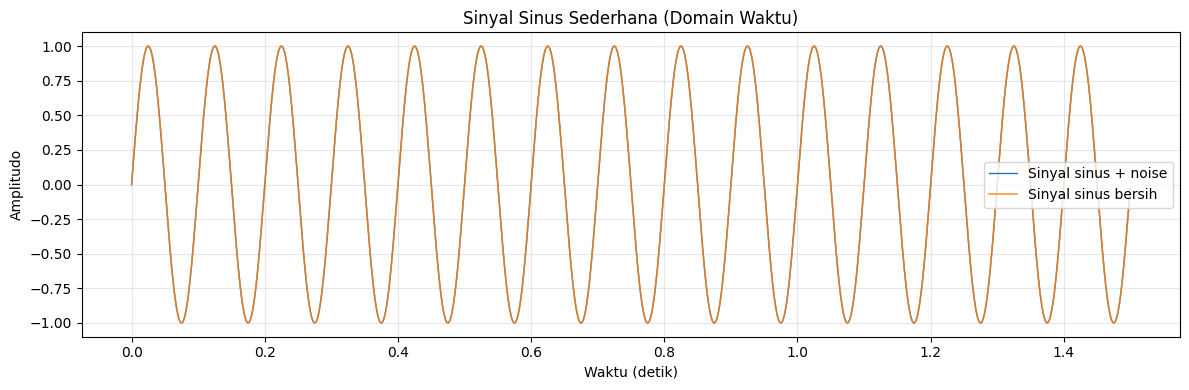

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

syn_fs = 2000           # Frekuensi sampling (Hz)
syn_duration = 1.5      # Durasi sinyal (detik)
syn_f0 = 10             # Frekuensi sinus utama (Hz)
syn_amp0 = 1.0          # Amplitudo sinus
syn_phase0 = 0.0        # Fase awal (radian)
syn_noise_std = 0.0     # Standar deviasi noise (0.0 = tanpa noise)
syn_random_seed = 42    # Benih acak agar hasil noise konsisten

t = np.arange(0, syn_duration, 1 / syn_fs)

syn_clean_signal = syn_amp0 * np.sin(2 * np.pi * syn_f0 * t + syn_phase0)

rng = np.random.default_rng(syn_random_seed)
syn_noise = rng.normal(0, syn_noise_std, size=t.shape)
syn_signal = syn_clean_signal + syn_noise

plt.figure(figsize=(12, 4))
plt.plot(t, syn_signal, lw=1.0, color="tab:blue", label="Sinyal sinus + noise")
plt.plot(t, syn_clean_signal, lw=1.2, color="tab:orange", alpha=0.8, label="Sinyal sinus bersih")
plt.title("Sinyal Sinus Sederhana (Domain Waktu)")
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

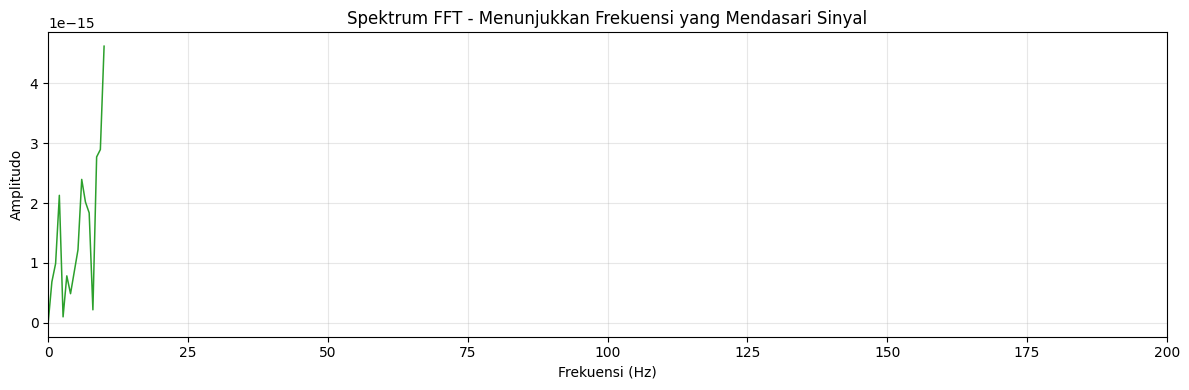

In [9]:
# Simpan untuk cell FFT berikutnya
syn_n = len(syn_signal)

syn_signal_centered = syn_signal - np.mean(syn_signal)

syn_freqs = np.fft.rfftfreq(syn_n, d=1 / syn_fs)
syn_fft_vals = np.fft.rfft(syn_signal_centered)
syn_amp = (2 / syn_n) * np.abs(syn_fft_vals)

plt.figure(figsize=(12, 4))
plt.plot(syn_freqs, syn_amp, color="tab:green", lw=1.1)
plt.title("Spektrum FFT - Menunjukkan Frekuensi yang Mendasari Sinyal")
plt.xlabel("Frekuensi (Hz)")
plt.ylabel("Amplitudo")
plt.grid(alpha=0.3)
plt.xlim(0, 200)
plt.tight_layout()
plt.show()

# Real Signal

In [6]:
import pandas as pd

with open(r"Dita pratama putra\ncv\1.csv", encoding="latin-1") as f:
    lines = f.readlines()

start = None
for i, line in enumerate(lines):
    if line.startswith("Trace Data"):
        start = i + 1
        break

data = []
for line in lines[start:]:
    parts = line.strip().split(";")
    if len(parts) < 3:
        break
    a = float(parts[1].replace(",", "."))
    b = float(parts[2].replace(",", "."))
    data.append([a, b])

df = pd.DataFrame(data, columns=["Ankle", "Knee"])
df.head()

,Ankle,Knee
0,-13241.598951,-10.718684
1,-22760.018424,-206.822493
2,-5486.132745,8.794133
3,452.894220,-19.833575
4,202.829927,-19.138598


In [7]:
import numpy as np
import plotly.graph_objects as go

dt = 0.0781
N = len(df)
df["Time"] = [i * dt for i in range(N)]

start_index = 10
df_cut = df.iloc[start_index:].reset_index(drop=True)

time = df_cut["Time"]
trace1 = df_cut["Ankle"]
trace2 = df_cut["Knee"]

offset = 2000
trace2_offset = trace2 - offset

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=time, 
    y=trace1, 
    mode='lines', 
    name='Ankle',
    line=dict(width=2)
))

fig.add_trace(go.Scatter(
    x=time, 
    y=trace2_offset, 
    mode='lines', 
    name='Knee',
    line=dict(width=2)
))

fig.update_layout(
    title="NCV Signals Comparison",
    xaxis_title="Time (ms)",
    yaxis_title="Amplitude (µV)",
    template="plotly_white",
    showlegend=True
)

fig.show()

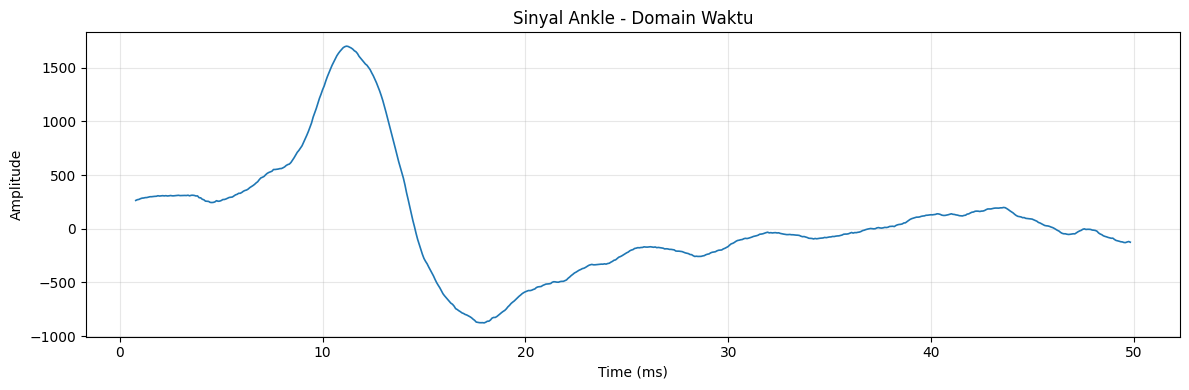

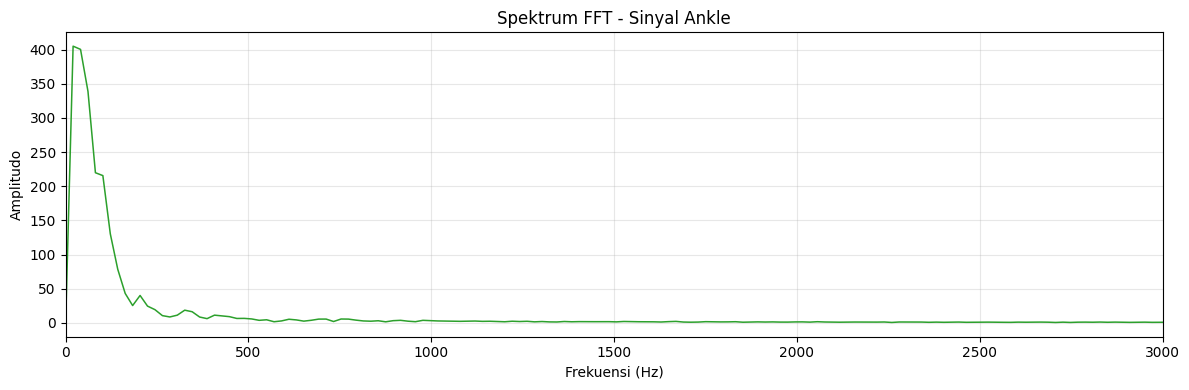

In [ ]:
# Ambil sinyal ankle dari data di atas
ankle_time = df_cut["Time"].to_numpy()
ankle_signal = df_cut["Ankle"].to_numpy()

# Plot domain waktu untuk ankle saja
plt.figure(figsize=(12, 4))
plt.plot(ankle_time, ankle_signal, color="tab:blue", lw=1.2)
plt.title("Sinyal Ankle - Domain Waktu")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# FFT ankle
ankle_n = len(ankle_signal)

ankle_signal_centered = ankle_signal - np.mean(ankle_signal)
time_step_ms = float(np.mean(np.diff(ankle_time)))
sample_period_s = time_step_ms / 1000.0
ankle_freqs = np.fft.rfftfreq(ankle_n, d=sample_period_s)
ankle_fft_vals = np.fft.rfft(ankle_signal_centered)
ankle_amp = (2 / ankle_n) * np.abs(ankle_fft_vals)

plt.figure(figsize=(12, 4))
plt.plot(ankle_freqs, ankle_amp, color="tab:green", lw=1.1)
plt.title("Spektrum FFT - Sinyal Ankle")
plt.xlabel("Frekuensi (Hz)")
plt.ylabel("Amplitudo")
plt.grid(alpha=0.3)
plt.xlim(0, min(3000, ankle_freqs.max()))
plt.tight_layout()
plt.show()
